In [1]:
# !pip install python-Levenshtein

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths, get_results_path
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "raw"
inject_roles = False
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
paths = get_dataset_paths(enhancement)

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)

In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

[DEBUG] raw Train Loss (Epoch 1): 1.5735
[DEBUG] raw Dev Eval (Epoch 1):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0011
  edit_distance_avg: 98.3267
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9867
[DEBUG] raw Train Loss (Epoch 2): 1.0448
[DEBUG] raw Dev Eval (Epoch 2):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0012
  edit_distance_avg: 100.9967
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9567
[DEBUG] raw Train Loss (Epoch 3): 0.8126
[DEBUG] raw Dev Eval (Epoch 3):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0012
  edit_distance_avg: 105.6100
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9267
[DEBUG] raw Train Loss (Epoch 4): 0.6534
[DEBUG] raw Dev Eval (Epoch 4):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0027
  edit_distance_avg: 106.6833
  predicate_accuracy: 0.0007
  valid_logical_form_ratio: 0.8033
[DEBUG] raw Train Loss (Epoch 5): 0.5292
[DEBUG] raw Dev Eval (Epoch 5):


Predictions saved to: /notebooks/meta-semantic-research/predictions/raw/t5-small_test_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/raw/t5-small_test_metrics.csv
[DEBUG] raw Test Eval:
  precision: 0.0017
  recall: 0.0011
  f1: 0.0013
  bleu: 0.0049
  edit_distance_avg: 112.6200
  predicate_accuracy: 0.0033
  valid_logical_form_ratio: 0.7267


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.0017,0.0011,0.0013,0.0049,112.6200,0.0033,0.7267


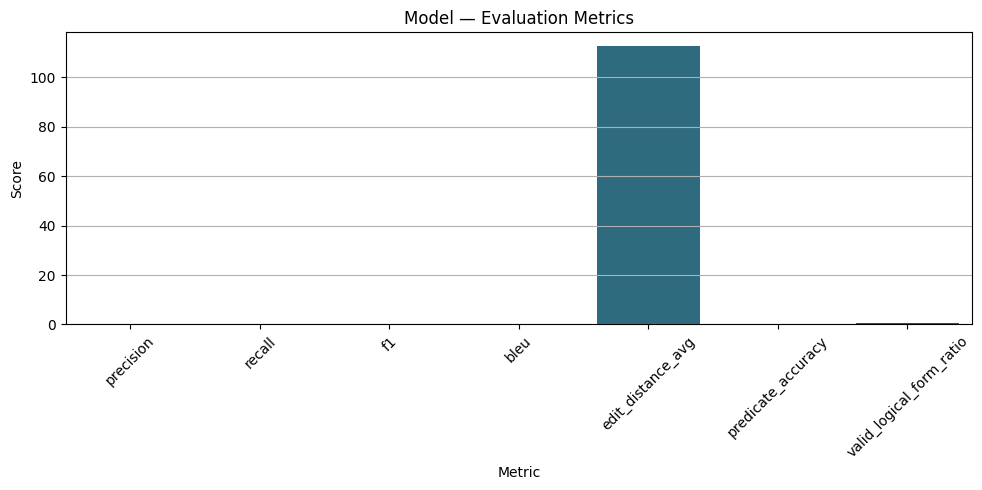

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(get_results_path(model_name, "test", enhancement))
plot_metrics_bar(get_results_path(model_name, "test", enhancement))

Predictions saved to: /notebooks/meta-semantic-research/predictions/raw/t5-small_gen_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/raw/t5-small_gen_metrics.csv
[DEBUG] raw Gen Eval:
  precision: 0.0010
  recall: 0.0006
  f1: 0.0007
  bleu: 0.0024
  edit_distance_avg: 161.8614
  predicate_accuracy: 0.0015
  valid_logical_form_ratio: 0.7905


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.0010,0.0006,0.0007,0.0024,161.8614,0.0015,0.7905


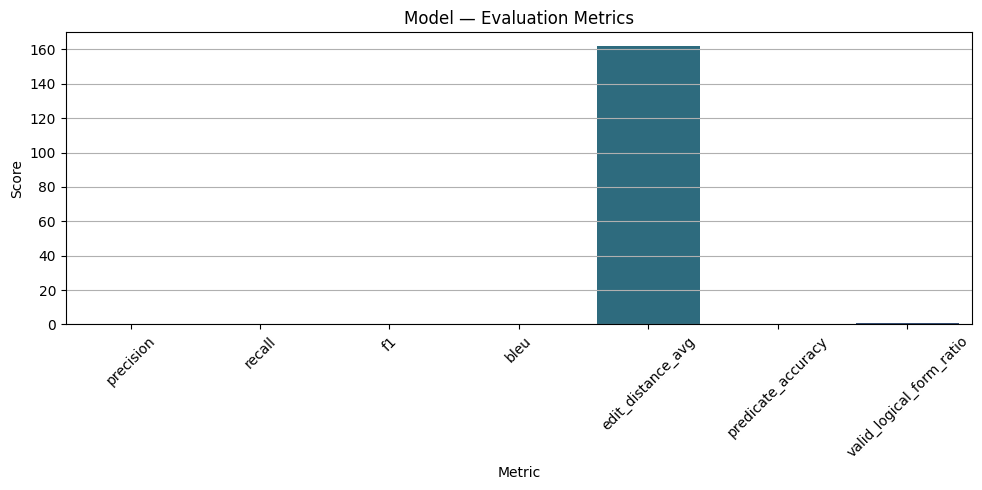

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(get_results_path(model_name, "gen", enhancement))
plot_metrics_bar(get_results_path(model_name, "gen", enhancement))

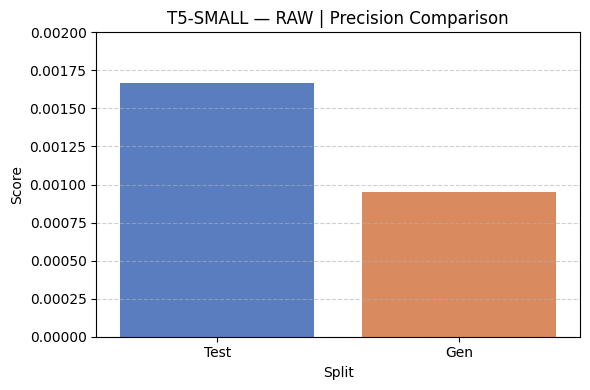

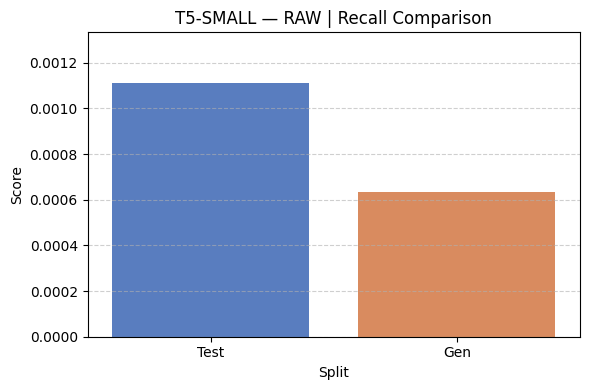

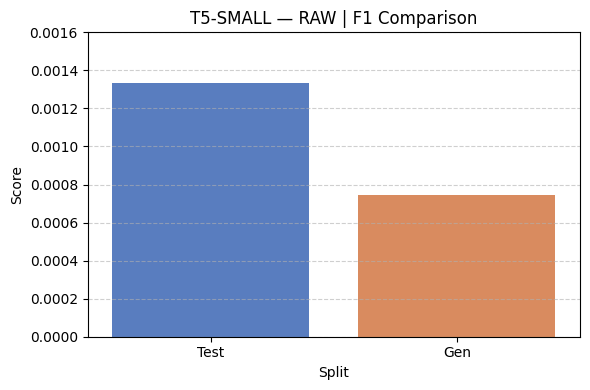

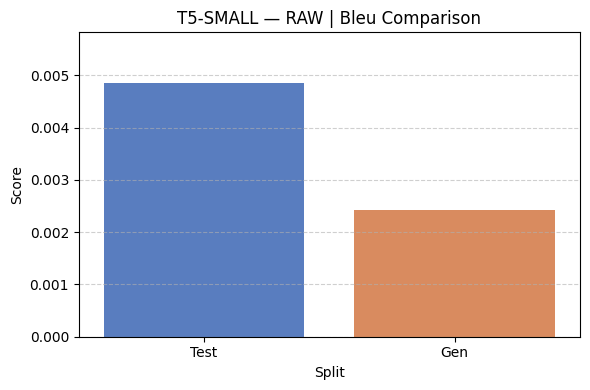

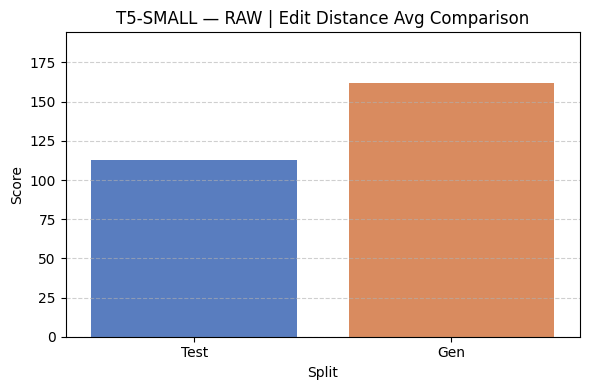

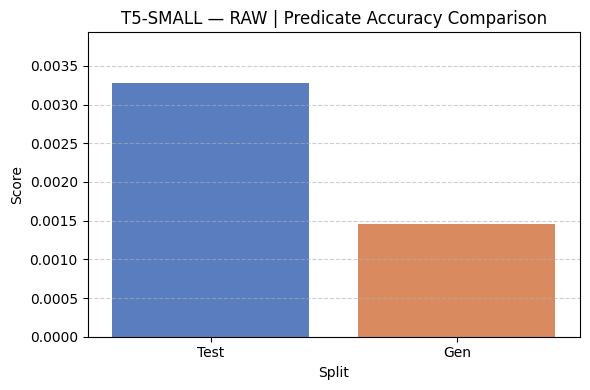

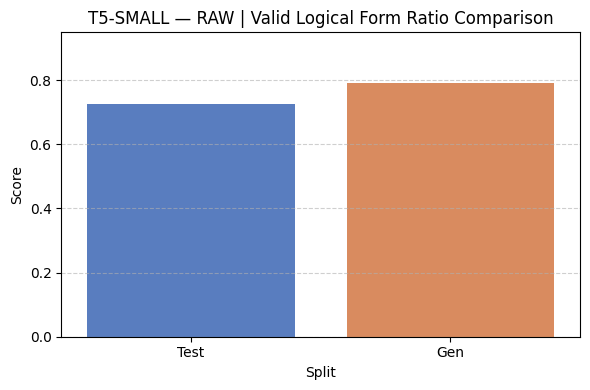

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)